In [1]:
import os

os.chdir("/home/abdul_basit/projects/restaurant_project/")
os.getcwd()

'/home/abdul_basit/projects/restaurant_project'

**OBJECTIVE 1: EXPLORING THE ITEMS TABLE**

1. View the menu_items 

In [ ]:
import pandas as pd

menu_items = pd.read_csv("Datasets/menu_items.csv")

menu_items.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


: 

: 

2. Write a query to find the number of items on the menu

In [ ]:
menu_items.agg(
    num_items= ("menu_item_id", "count")
)

,menu_item_id
num_items,32


: 

: 

3. What are the least and most expensive items on the menu?

In [ ]:
least_expensive = (
    menu_items
    .sort_values("price")
)

least_expensive.head()


,menu_item_id,item_name,category,price
12,113,Edamame,Asian,5.0
5,106,French Fries,American,7.0
4,105,Mac & Cheese,American,7.0
21,122,Chips & Salsa,Mexican,7.0
13,114,Potstickers,Asian,9.0


: 

: 

In [ ]:
most_expensive = (
    menu_items
    .sort_values("price", ascending=False)
)

most_expensive.head()

,menu_item_id,item_name,category,price
29,130,Shrimp Scampi,Italian,19.95
9,110,Pork Ramen,Asian,17.95
26,127,Meat Lasagna,Italian,17.95
8,109,Korean Beef Bowl,Asian,17.95
30,131,Chicken Parmesan,Italian,17.95


: 

: 

4. How many italian dishes are on the menu? 

In [ ]:
(menu_items
 .query("category == 'Italian'")
 .agg(
     num_italian = ("item_name", "count")
 )
)

,item_name
num_italian,9


: 

: 

5. What are the least and most expensive italian dishes on the menu.

In [ ]:
least_expensive_italian = (
    menu_items
    .query("category == 'Italian'")
    .sort_values("price")
)

least_expensive_italian.head()

,menu_item_id,item_name,category,price
23,124,Spaghetti,Italian,14.50
25,126,Fettuccine Alfredo,Italian,14.50
28,129,Mushroom Ravioli,Italian,15.50
27,128,Cheese Lasagna,Italian,15.50
31,132,Eggplant Parmesan,Italian,16.95


: 

: 

In [ ]:
most_expensive_italian = (
    menu_items
    .query("category == 'Italian'")
    .sort_values("price", ascending=False)
)

most_expensive_italian.head()

,menu_item_id,item_name,category,price
29,130,Shrimp Scampi,Italian,19.95
30,131,Chicken Parmesan,Italian,17.95
24,125,Spaghetti & Meatballs,Italian,17.95
26,127,Meat Lasagna,Italian,17.95
31,132,Eggplant Parmesan,Italian,16.95


: 

: 

6. How many dishes are  in each category? 

In [ ]:
(menu_items
 .groupby("category")
 .agg(
     num_dishes = ("item_name", "count")
 )
)

,num_dishes
category,
American,6
Asian,8
Italian,9
Mexican,9


: 

: 

7. What is the average dish price within each category?

In [ ]:
(menu_items
 .groupby("category")
 .agg(
     avg_dish_price = ("price", "mean")
 ).round(2)
)

,avg_dish_price
category,
American,10.07
Asian,13.48
Italian,16.75
Mexican,11.80


: 

: 

**OBJECTIVE 2:**

1. view the order_details table

In [ ]:
order_details = pd.read_csv(
    "Datasets/order_details.csv",
    parse_dates=["order_date"])

order_details.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,2023-01-01,11:38:36,109.0
1,2,2,2023-01-01,11:57:40,108.0
2,3,2,2023-01-01,11:57:40,124.0
3,4,2,2023-01-01,11:57:40,117.0
4,5,2,2023-01-01,11:57:40,129.0


: 

: 

2. What is the date range of the table?

In [ ]:
order_date = (
    order_details.loc[:, ["order_date"]]
)

order_date.describe()

,order_date
count,12234
mean,2023-02-14 11:01:44.168710
min,2023-01-01 00:00:00
25%,2023-01-23 00:00:00
50%,2023-02-14 00:00:00
75%,2023-03-09 00:00:00
max,2023-03-31 00:00:00


: 

: 

3. How many order where made within this date range?

In [ ]:
(order_details
 .agg(
     num_orders = ("order_id", "nunique")
 )
)


,order_id
num_orders,5370


: 

: 

4. How many items where ordered within this date range?

In [ ]:
(order_details
 .agg(
     num_itemss = ("item_id", "count")
 )
)

,item_id
num_itemss,12097


: 

: 

In [ ]:
order_details["item_id"].count()

np.int64(12097)

: 

: 

5. Which orders have the most number of items?

In [ ]:
(order_details
 .groupby("order_id")
 .agg(
     num_items = ("item_id", "count")
 ).sort_values("num_items", ascending=False)
)

,num_items
order_id,
3473,14
330,14
2675,14
440,14
1957,14
...,...
822,0
200,0
147,0


: 

: 

6. How many orders have more than 12 items?

In [ ]:
(order_details
 .groupby("order_id")
 .agg(
     num_items = ("item_id", "count")
 )
 .query("num_items > 12")
).count()

num_items    20
dtype: int64

: 

: 

7. How many orders are made on each date?

In [ ]:
num_orders_per_date = (
    order_details
    .set_index("order_date")
    .resample("W-MON")
    .agg(
        num_orders = ("order_id", "count")
    )
)

num_orders_per_date.head()

,num_orders
order_date,
2023-01-02,321
2023-01-09,952
2023-01-16,916
2023-01-23,950
2023-01-30,874


: 

: 

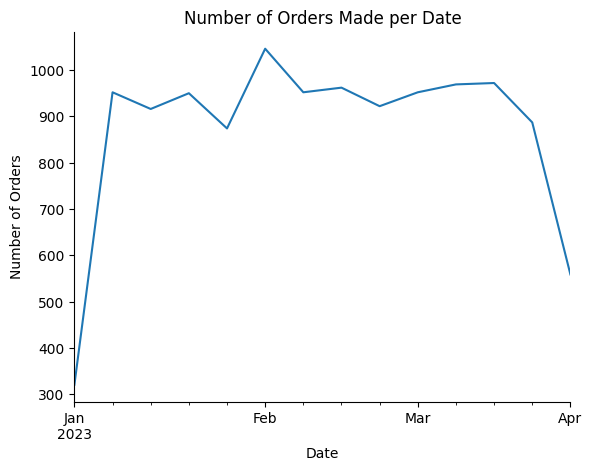

: 

: 

In [ ]:
import seaborn as sns

(num_orders_per_date
 .plot(
     title="Number of Orders Made per Date",
     xlabel="Date",
     ylabel="Number of Orders",
     legend=None
 )
)

sns.despine()

8. How many items are sold on each date?

In [ ]:
num_items_per_date = (
    order_details
    .set_index("order_date")
    .resample("W-MON")
    .agg(
        num_items = ("item_id", "count")
    )
)

num_items_per_date.head()

,num_items
order_date,
2023-01-02,319
2023-01-09,940
2023-01-16,902
2023-01-23,939
2023-01-30,863


: 

: 

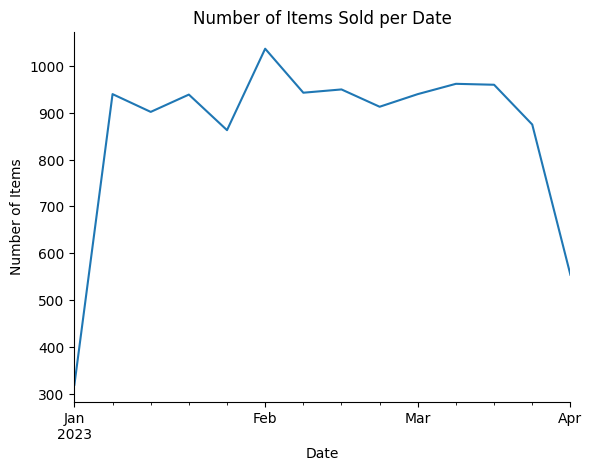

: 

: 

In [ ]:
(num_items_per_date
 .plot(
     title="Number of Items Sold per Date",
     xlabel="Date",
     ylabel="Number of Items",
     legend=None
 )
)

sns.despine()

**OBJECTIVE 3:**

1. Combine the menu_items and the order_details table into a single table

In [ ]:
new_df = pd.merge(
    order_details, 
    menu_items, 
    left_on='item_id', 
    right_on='menu_item_id', 
    how='left'
)

new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  datetime64[us]
 3   order_time        12234 non-null  str           
 4   item_id           12097 non-null  float64       
 5   menu_item_id      12097 non-null  float64       
 6   item_name         12097 non-null  str           
 7   category          12097 non-null  str           
 8   price             12097 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 860.3 KB


: 

: 

2. What were the least and most ordered items? What categories where they in?

In [ ]:
least_ordered = (
    new_df
    .groupby(["item_name", "category"])
    .agg(
        num_purchases =("item_id", "count")
    )
    .sort_values("num_purchases")
)

least_ordered.head()

,,num_purchases
item_name,category,
Chicken Tacos,Mexican,123
Potstickers,Asian,205
Cheese Lasagna,Italian,207
Steak Tacos,Mexican,214
Cheese Quesadillas,Mexican,233


: 

: 

In [ ]:
most_ordered = (
    new_df
    .groupby(["item_name", "category"])
    .agg(
        num_purchases =("item_id", "count")
    )
    .sort_values("num_purchases", ascending=False)
)

most_ordered.head()

,,num_purchases
item_name,category,
Hamburger,American,622
Edamame,Asian,620
Korean Beef Bowl,Asian,588
Cheeseburger,American,583
French Fries,American,571


: 

: 

3. What were the top 5 orders that spent the most money?

In [ ]:
amount_spent_per_order = (
    new_df
    .groupby("order_id")
    .agg(
        spent_amount = ("price", "sum")
    )
    .sort_values("spent_amount", ascending=False)
)

amount_spent_per_order.head()

,spent_amount
order_id,
440,192.15
2075,191.05
1957,190.10
330,189.70
2675,185.10


: 

: 

4. View the details of the highest spent order. What insights can you gather

In [ ]:
(new_df
 .query("order_id == 440")
)


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
1002,1003,440,2023-01-08,12:16:34,116.0,116.0,Steak Tacos,Mexican,13.95
1003,1004,440,2023-01-08,12:16:34,103.0,103.0,Hot Dog,American,9.00
1004,1005,440,2023-01-08,12:16:34,124.0,124.0,Spaghetti,Italian,14.50
1005,1006,440,2023-01-08,12:16:34,125.0,125.0,Spaghetti & Meatballs,Italian,17.95
1006,1007,440,2023-01-08,12:16:34,125.0,125.0,Spaghetti & Meatballs,Italian,17.95
1007,1008,440,2023-01-08,12:16:34,126.0,126.0,Fettuccine Alfredo,Italian,14.50
1008,1009,440,2023-01-08,12:16:34,126.0,126.0,Fettuccine Alfredo,Italian,14.50
1009,1010,440,2023-01-08,12:16:34,109.0,109.0,Korean Beef Bowl,Asian,17.95
1010,1011,440,2023-01-08,12:16:34,127.0,127.0,Meat Lasagna,Italian,17.95
1011,1012,440,2023-01-08,12:16:34,113.0,113.0,Edamame,Asian,5.00


: 

: 

5. View the details of the top 5 highest spent order. What insights can you gather

In [ ]:
(new_df
 .query("order_id == [440, 2075, 1975, 330, 2675]")
 .groupby(["order_id", "category"])
 .agg(
     num_items = ("item_id", "count")
 )
)

num_items
order_id category           
330      American          1
         Asian             6
         Italian           3
         Mexican           4
440      American          2
         Asian             2
         Italian           8
         Mexican           2
1975     Asian             2
2075     American          1
         Asian             3
         Italian           6
         Mexican           3
2675     American          3
         Asian             3
         Italian           4
         Mexican           4

: 

: 